In [1]:
import subprocess
subprocess.run(["pip", "install", "shap"], capture_output=True)
print("SHAP installed ✓")

SHAP installed ✓


In [2]:
import shap
print(f"SHAP version: {shap.__version__} ✓")

SHAP version: 0.51.0 ✓


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import shap
import joblib
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
np.random.seed(42)

print("All imports successful ✓")

All imports successful ✓


In [4]:
# Load everything we built in Phase 1
rf_model     = joblib.load('../models/random_forest.pkl')
feature_cols = joblib.load('../models/feature_cols.pkl')

X_train = pd.read_csv('../data/X_train.csv')
X_test  = pd.read_csv('../data/X_test.csv')
y_test  = pd.read_csv('../data/y_test.csv').squeeze()

print(f"Model loaded      : Random Forest ({rf_model.n_estimators} trees)")
print(f"Features          : {len(feature_cols)}")
print(f"X_train shape     : {X_train.shape}")
print(f"X_test shape      : {X_test.shape}")

Model loaded      : Random Forest (200 trees)
Features          : 26
X_train shape     : (20268, 26)
X_test shape      : (4400, 26)


In [5]:
# SHAP = SHapley Additive exPlanations
#
# For every single prediction, SHAP answers:
# "How much did each feature PUSH the prediction UP or DOWN?"
#
# Example for a Delhi prediction of AQI = 320:
#
#   Base value (average AQI)     = 166.5
#   + AQI_lag_1 contribution     = +52.3  (yesterday was also high)
#   + PM2.5 contribution         = +38.1  (PM2.5 is very high today)
#   + AQI_rolling_7d             = +31.2  (week trend is bad)
#   + Season_encoded             = +18.4  (it's winter)
#   - O3 contribution            = -5.1   (ozone is low, slightly helps)
#   + ...other features          = +18.6
#   ─────────────────────────────────────
#   Final prediction             = 320.0  ✓
#
# This is what we will visualize — for EACH prediction.

print("SHAP concept understood ✓")
print(f"\nBase AQI (average in training): {y_test.mean():.1f}")
print("SHAP will explain deviations from this base value.")

SHAP concept understood ✓

Base AQI (average in training): 112.4
SHAP will explain deviations from this base value.


In [6]:
print("Creating SHAP TreeExplainer...")

explainer = shap.TreeExplainer(rf_model)

# Fix: expected_value is an array for RF — take the mean
base_value = float(np.mean(explainer.expected_value))

print("Explainer created ✓")
print(f"Expected value (base): {base_value:.2f}")

Creating SHAP TreeExplainer...
Explainer created ✓
Expected value (base): 171.44


In [7]:
# Use a sample of 500 rows — enough for global analysis
# Full test set would work but takes longer
sample_size = 500
X_sample = X_test.sample(sample_size, random_state=42).reset_index(drop=True)

print(f"Computing SHAP values for {sample_size} test samples...")
print("This takes 1-3 minutes on CPU...")

shap_values = explainer.shap_values(X_sample)

print(f"\nSHAP values computed ✓")
print(f"Shape: {shap_values.shape}  → (samples × features)")
print(f"Each value = how much that feature pushed AQI up or down")
print(f"\nExample — first prediction:")
print(f"  Actual AQI    : {y_test.iloc[:500].values[0]:.1f}")
print(f"  Top SHAP push : +{shap_values[0].max():.2f} from feature '{feature_cols[shap_values[0].argmax()]}'")

Computing SHAP values for 500 test samples...
This takes 1-3 minutes on CPU...

SHAP values computed ✓
Shape: (500, 26)  → (samples × features)
Each value = how much that feature pushed AQI up or down

Example — first prediction:
  Actual AQI    : 216.0
  Top SHAP push : +1.16 from feature 'City_encoded'


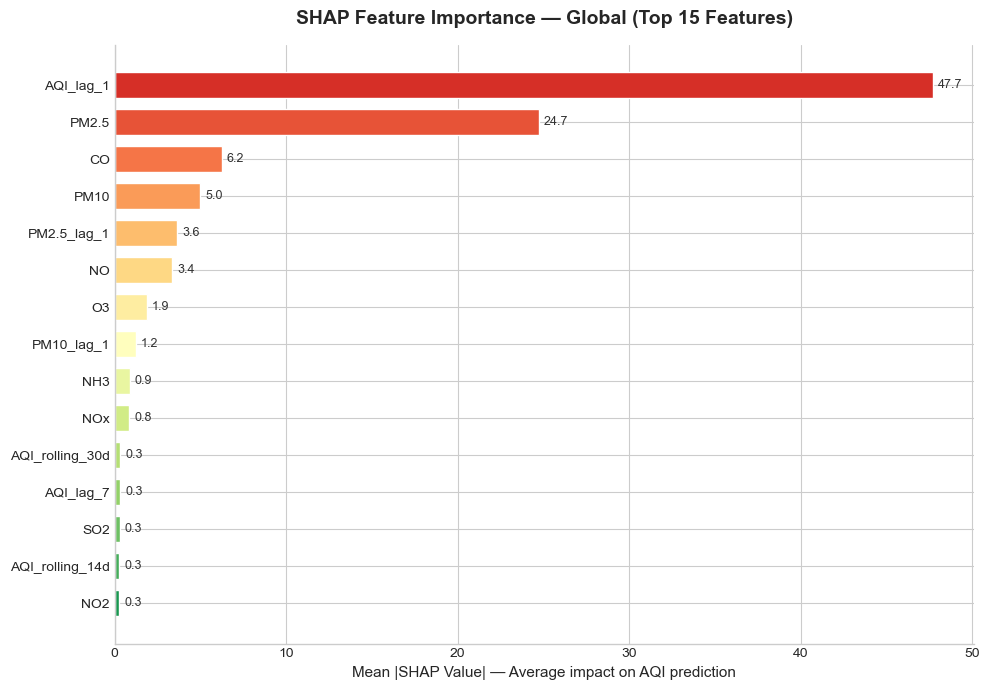

Plot 1 saved ✓


In [8]:
# This shows AVERAGE |SHAP value| per feature across all 500 samples
# = Which features matter MOST overall

mean_shap = np.abs(shap_values).mean(axis=0)
shap_importance = pd.Series(mean_shap, index=feature_cols).sort_values(ascending=True)

# Take top 15
top15 = shap_importance.tail(15)

fig, ax = plt.subplots(figsize=(10, 7))

colors = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(top15)))
bars = ax.barh(top15.index, top15.values,
               color=colors, edgecolor='white', height=0.7)

# Add value labels
for bar, val in zip(bars, top15.values):
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}', va='center', fontsize=9, color='#333')

ax.set_title('SHAP Feature Importance — Global (Top 15 Features)',
             fontweight='bold', fontsize=14, pad=15)
ax.set_xlabel('Mean |SHAP Value| — Average impact on AQI prediction', fontsize=11)
ax.set_ylabel('')
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('../visualizations/13_shap_global_importance.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Plot 1 saved ✓")

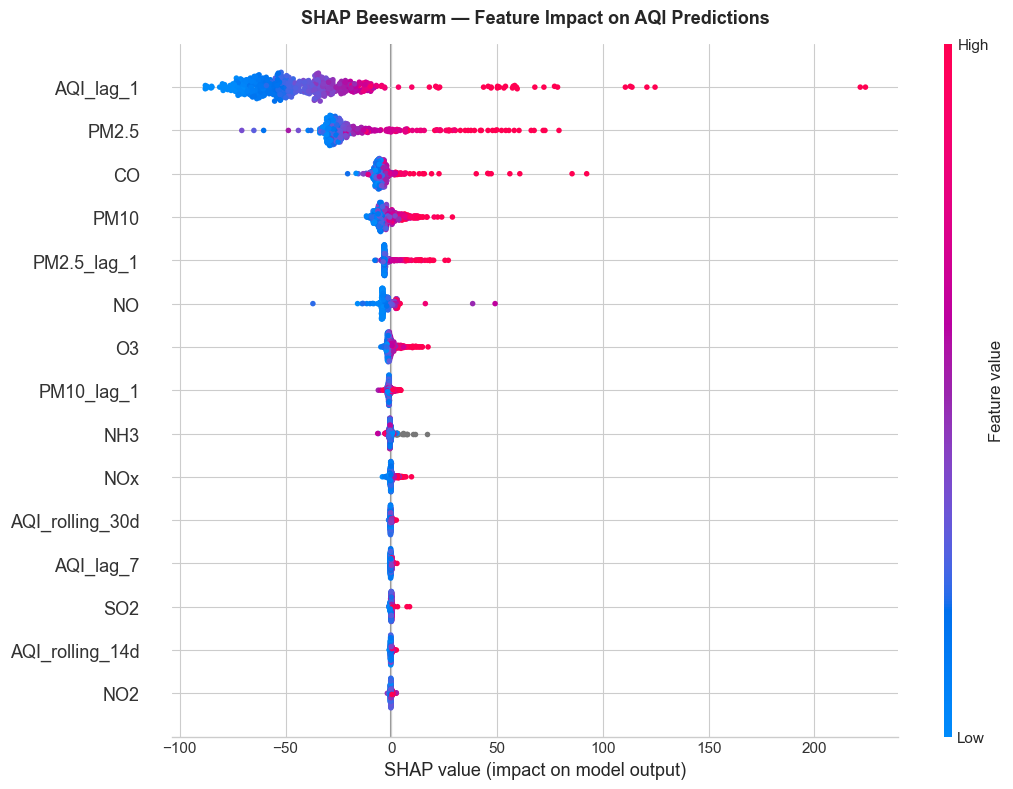

Plot 2 saved ✓

HOW TO READ THIS PLOT:
  Each dot = one prediction
  Red dot  = high value of that feature
  Blue dot = low value of that feature
  Right    = pushed AQI prediction HIGHER
  Left     = pushed AQI prediction LOWER


In [9]:
# Beeswarm shows BOTH direction AND magnitude for each feature
# Red dots = high feature value, Blue = low feature value
# Right of center = pushed AQI UP, Left = pushed AQI DOWN

plt.figure(figsize=(11, 8))

shap.summary_plot(
    shap_values,
    X_sample,
    feature_names=feature_cols,
    max_display=15,
    show=False,
    plot_size=None
)

plt.title('SHAP Beeswarm — Feature Impact on AQI Predictions',
          fontweight='bold', fontsize=13, pad=15)
plt.tight_layout()
plt.savefig('../visualizations/14_shap_beeswarm.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Plot 2 saved ✓")
print()
print("HOW TO READ THIS PLOT:")
print("  Each dot = one prediction")
print("  Red dot  = high value of that feature")
print("  Blue dot = low value of that feature")
print("  Right    = pushed AQI prediction HIGHER")
print("  Left     = pushed AQI prediction LOWER")

Explaining prediction #56
  Predicted AQI : 420.6
  Actual AQI    : 475.0
  Error         : 54.4 AQI units


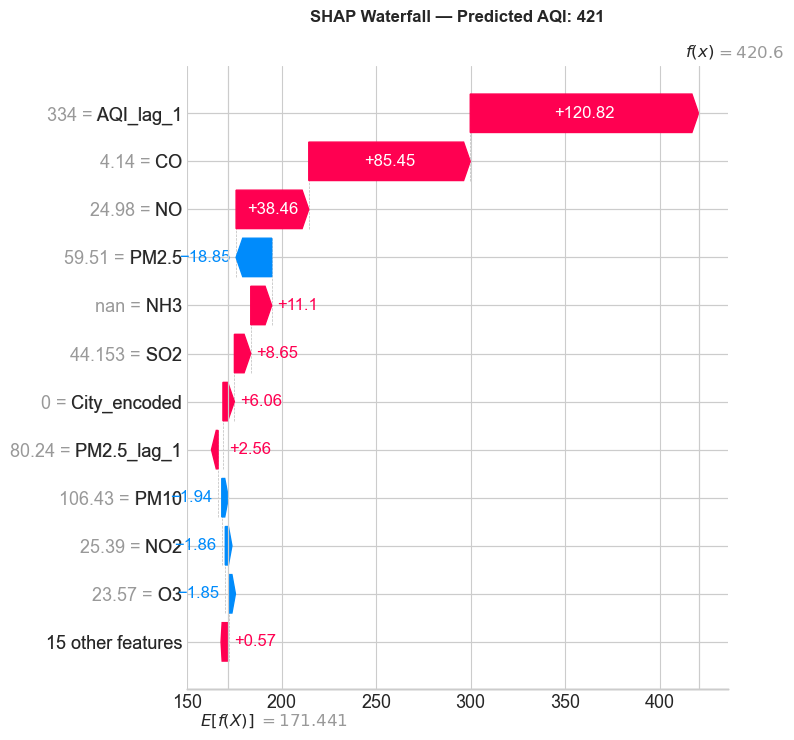

Plot 3 saved ✓


In [10]:
# Self-contained — no dependency on previous cells
y_pred_sample = rf_model.predict(X_sample)

# Find a high AQI prediction to explain
high_aqi_idx = np.where(y_pred_sample > 300)[0]
idx = high_aqi_idx[0] if len(high_aqi_idx) > 0 else np.argmax(y_pred_sample)

pred_aqi   = y_pred_sample[idx]
actual_aqi = y_test.iloc[:500].values[idx]

print(f"Explaining prediction #{idx}")
print(f"  Predicted AQI : {pred_aqi:.1f}")
print(f"  Actual AQI    : {actual_aqi:.1f}")
print(f"  Error         : {abs(pred_aqi - actual_aqi):.1f} AQI units")

explanation = shap.Explanation(
    values=shap_values[idx],
    base_values=base_value,
    data=X_sample.iloc[idx].values,
    feature_names=feature_cols
)

plt.figure(figsize=(11, 7))
shap.waterfall_plot(explanation, max_display=12, show=False)
plt.title(f'SHAP Waterfall — Predicted AQI: {pred_aqi:.0f}',
          fontweight='bold', fontsize=12, pad=15)
plt.tight_layout()
plt.savefig('../visualizations/15_shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot 3 saved ✓")

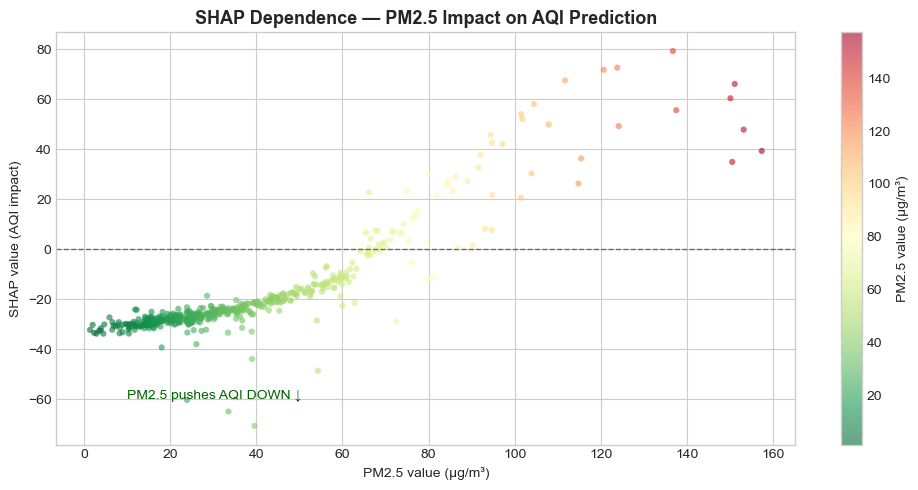

Plot 4 saved ✓


In [11]:
# Shows how PM2.5 values relate to their SHAP contribution
# i.e., "how does increasing PM2.5 affect the prediction?"

plt.figure(figsize=(10, 5))

pm25_idx   = feature_cols.index('PM2.5')
pm25_vals  = X_sample['PM2.5'].values
pm25_shap  = shap_values[:, pm25_idx]

scatter = plt.scatter(pm25_vals, pm25_shap,
                      c=pm25_vals, cmap='RdYlGn_r',
                      alpha=0.6, s=20, edgecolors='none')

plt.colorbar(scatter, label='PM2.5 value (μg/m³)')
plt.axhline(0, color='black', linewidth=1, linestyle='--', alpha=0.5)
plt.title('SHAP Dependence — PM2.5 Impact on AQI Prediction',
          fontweight='bold', fontsize=13)
plt.xlabel('PM2.5 value (μg/m³)')
plt.ylabel('SHAP value (AQI impact)')
plt.annotate('PM2.5 pushes AQI UP ↑', xy=(180, pm25_shap.max()*0.85),
             fontsize=10, color='darkred')
plt.annotate('PM2.5 pushes AQI DOWN ↓', xy=(10, pm25_shap.min()*0.85),
             fontsize=10, color='darkgreen')
plt.tight_layout()
plt.savefig('../visualizations/16_shap_pm25_dependence.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Plot 4 saved ✓")

In [12]:
# This function generates a human-readable explanation for ANY prediction
# We'll use this in the Streamlit app later

def explain_prediction_text(shap_vals, feature_names, predicted_aqi, base_aqi):
    """
    Generates a natural language explanation of a prediction
    using its SHAP values.
    """
    # Get top 3 positive and negative contributors
    shap_series = pd.Series(shap_vals, index=feature_names)
    top_positive = shap_series.nlargest(3)
    top_negative = shap_series.nsmallest(2)

    # Format feature names nicely
    def fmt(name):
        return (name.replace('AQI_lag_', 'AQI ')
                    .replace('AQI_rolling_', '')
                    .replace('_lag_1', ' (yesterday)')
                    .replace('_encoded', '')
                    .replace('_', ' '))

    lines = []
    lines.append(f"Predicted AQI: {predicted_aqi:.0f} "
                 f"(base average: {base_aqi:.0f})")
    lines.append("")
    lines.append("Main factors INCREASING this prediction:")
    for feat, val in top_positive.items():
        lines.append(f"  ↑ {fmt(feat):<28} +{val:.1f} AQI points")

    if (top_negative < 0).any():
        lines.append("\nMain factors DECREASING this prediction:")
        for feat, val in top_negative.items():
            if val < 0:
                lines.append(f"  ↓ {fmt(feat):<28} {val:.1f} AQI points")

    return "\n".join(lines)

# Test it on our high-AQI prediction
explanation_text = explain_prediction_text(
    shap_values[idx],
    feature_cols,
    pred_aqi,
    base_value        # ← use base_value here too
)
print(explanation_text)

Predicted AQI: 421 (base average: 171)

Main factors INCREASING this prediction:
  ↑ AQI 1                        +120.8 AQI points
  ↑ CO                           +85.5 AQI points
  ↑ NO                           +38.5 AQI points

Main factors DECREASING this prediction:
  ↓ PM2.5                        -18.9 AQI points
  ↓ PM10                         -1.9 AQI points


In [13]:
import os

# Save SHAP values and explainer for use in app
joblib.dump(explainer,         '../models/shap_explainer.pkl')
joblib.dump(shap_values,       '../models/shap_values_sample.pkl')
joblib.dump(X_sample,          '../models/X_shap_sample.pkl')

# Save global importance as CSV (easy to load in app)
shap_importance_df = pd.DataFrame({
    'Feature'   : feature_cols,
    'SHAP_Mean' : mean_shap,
    'SHAP_Rank' : pd.Series(mean_shap).rank(ascending=False).astype(int)
}).sort_values('SHAP_Rank')

shap_importance_df.to_csv('../data/shap_importance.csv', index=False)

print("SHAP artifacts saved:")
print("  models/shap_explainer.pkl        ← TreeExplainer object")
print("  models/shap_values_sample.pkl    ← pre-computed SHAP values")
print("  models/X_shap_sample.pkl         ← corresponding input rows")
print("  data/shap_importance.csv         ← feature importance table")

SHAP artifacts saved:
  models/shap_explainer.pkl        ← TreeExplainer object
  models/shap_values_sample.pkl    ← pre-computed SHAP values
  models/X_shap_sample.pkl         ← corresponding input rows
  data/shap_importance.csv         ← feature importance table


In [15]:
top5_features = shap_importance.tail(5).index.tolist()[::-1]
print(f"""
  Samples explained : {sample_size}
  Plots created     : 4
    13_shap_global_importance.png
    14_shap_beeswarm.png
    15_shap_waterfall.png
    16_shap_pm25_dependence.png

  Top 5 features by SHAP importance:
""")
for i, feat in enumerate(top5_features, 1):
    val = shap_importance[feat]
    print(f"    {i}. {feat:<28} avg impact: {val:.1f} AQI")

print(f"""
  Key insight:
  AQI_lag_1 dominates predictions — confirming
  that recent pollution history is the strongest
  signal for AQI estimation.

  SHAP artifacts saved to models/ and data/
  Ready for Streamlit integration on Day 9.
""")
print("=" * 50)


  Samples explained : 500
  Plots created     : 4
    13_shap_global_importance.png
    14_shap_beeswarm.png
    15_shap_waterfall.png
    16_shap_pm25_dependence.png

  Top 5 features by SHAP importance:

    1. AQI_lag_1                    avg impact: 47.7 AQI
    2. PM2.5                        avg impact: 24.7 AQI
    3. CO                           avg impact: 6.2 AQI
    4. PM10                         avg impact: 5.0 AQI
    5. PM2.5_lag_1                  avg impact: 3.6 AQI

  Key insight:
  AQI_lag_1 dominates predictions — confirming
  that recent pollution history is the strongest
  signal for AQI estimation.

  SHAP artifacts saved to models/ and data/
  Ready for Streamlit integration on Day 9.

